### **Zachłanne kolorowanie grafu i liczba chromatyczna**

Kolorowanie grafu polega na przypisaniu kolorów do wierzchołków tak, aby żadne dwa sąsiednie wierzchołki nie miały tego samego koloru. Jest to klasyczny problem teorii grafów oraz optymalizacji dyskretnej.

Zagadnienie to ma wiele zastosowań praktycznych, na przykład w układaniu planów zajęć, przydzielaniu zasobów, harmonogramowaniu zadań oraz w problemach związanych z sieciami komputerowymi.

W tym projekcie porównane zostały dwa podejścia:

\- algorytm zachłanny,

\- wyznaczanie liczby chromatycznej metodą dokładną.

Algorytm zachłanny działa szybko, ale nie zawsze daje wynik optymalny. Liczba chromatyczna jest natomiast minimalną liczbą kolorów potrzebną do poprawnego pokolorowania grafu.



### Reprezentacja grafu

Graf będzie przechowywany w postaci listy sąsiedztwa. Dla każdego wierzchołka zapisujemy listę jego sąsiadów.

Taka reprezentacja jest wygodna, czytelna i dobrze nadaje się do implementacji algorytmów kolorowania.

W projekcie można także wczytać graf od użytkownika, ale dla przykładu działania zostanie użyty gotowy graf zapisany bezpośrednio w kodzie.



In [1]:
def read_graph():
    n = int(input("Podaj liczbę wierzchołków: "))
    m = int(input("Podaj liczbę krawędzi: "))

    adj = [[] for _ in range(n)]

    print("Podawaj krawędzie w formacie: u v")
    print("Wierzchołki numerujemy od 0 do n-1")

    for i in range(m):
        u, v = map(int, input(f"Krawędź {i + 1}: ").split())

        if v not in adj[u]:
            adj[u].append(v)
        if u not in adj[v]:
            adj[v].append(u)

    return adj


def print_coloring(colors):
    for v, c in enumerate(colors):
        print(f"Wierzchołek {v} -> kolor {c}")

In [2]:
def print_coloring(colors):
    for v, c in enumerate(colors):
        print(f"Wierzchołek {v} -> kolor {c}")


def greedy_coloring_order(adj, order):
    """
    Zachłanne kolorowanie grafu w zadanej kolejności wierzchołków.
    Dla każdego wierzchołka wybierany jest najmniejszy możliwy kolor.
    """
    n = len(adj)
    colors = [-1] * n

    for v in order:
        used_colors = {colors[u] for u in adj[v] if colors[u] != -1}
        color = 0

        while color in used_colors:
            color += 1

        colors[v] = color

    return colors


def largest_first_order(adj):
    """
    Porządek LF (Largest First):
    najpierw wierzchołki o największym stopniu.
    """
    return sorted(range(len(adj)), key=lambda v: len(adj[v]), reverse=True)


def smallest_last_order(adj):
    """
    Porządek SL (Smallest Last):
    usuwamy kolejno wierzchołki o najmniejszym stopniu,
    a potem odwracamy otrzymaną kolejność.
    """
    n = len(adj)
    remaining = set(range(n))
    degrees = [len(adj[v]) for v in range(n)]
    removal_order = []

    while remaining:
        v = min(remaining, key=lambda x: degrees[x])
        removal_order.append(v)
        remaining.remove(v)

        for u in adj[v]:
            if u in remaining:
                degrees[u] -= 1

    return list(reversed(removal_order))


def degeneracy(adj):
    """
    Degeneracja grafu:
    d(G) = max_{H subseteq G} delta(H)
    """
    n = len(adj)
    remaining = set(range(n))
    degrees = [len(adj[v]) for v in range(n)]
    d = 0

    while remaining:
        v = min(remaining, key=lambda x: degrees[x])
        d = max(d, degrees[v])
        remaining.remove(v)

        for u in adj[v]:
            if u in remaining:
                degrees[u] -= 1

    return d


def greedy_coloring_lf(adj):
    """
    Kolorowanie zachłanne w porządku LF.
    """
    order = largest_first_order(adj)
    return greedy_coloring_order(adj, order)


def greedy_coloring_sl(adj):
    """
    Kolorowanie zachłanne w porządku SL.
    """
    order = smallest_last_order(adj)
    return greedy_coloring_order(adj, order)

### Algorytm zachłanny

Algorytm zachłanny przegląda wierzchołki po kolei i dla każdego z nich wybiera najmniejszy dostępny kolor, który nie występuje u jego sąsiadów.

Zaletą tego podejścia jest prostota oraz szybkie działanie. Wadą jest to, że algorytm nie gwarantuje znalezienia minimalnej liczby kolorów.

W tym projekcie zastosowano prostą wersję zachłanną, w której wierzchołki są przetwarzane w kolejności 0, 1, 2, ..., n\-1.



In [3]:
#Przykładowy graf:
# 0 --- 3
#       |
# 1 --- 2

adj = [
    [3],      # 0
    [2],      # 1
    [1, 3],   # 2
    [0, 2]    # 3
]

print("Lista sąsiedztwa:")
print(adj)

greedy = greedy_coloring_sl(adj) #smallest first
print("\nKolorowanie zachłanne:")
print_coloring(greedy)

#kolory numeruję od zera, dlatego największy numer koloru nie oznacza liczby kolorów
greedy_colors_used = max(greedy) + 1
print(f"\nLiczba kolorów użyta przez algorytm zachłanny: {greedy_colors_used}")

Lista sąsiedztwa:
[[3], [2], [1, 3], [0, 2]]

Kolorowanie zachłanne:
Wierzchołek 0 -> kolor 1
Wierzchołek 1 -> kolor 0
Wierzchołek 2 -> kolor 1
Wierzchołek 3 -> kolor 0

Liczba kolorów użyta przez algorytm zachłanny: 2


In [4]:
def is_safe(v, color, colors, adj):
    """
    Sprawdza, czy można przypisać wierzchołkowi v kolor color.
    Kolor jest poprawny tylko wtedy, gdy żaden sąsiad nie ma tego samego koloru.
    """
    for u in adj[v]:
        if colors[u] == color:
            return False
    return True


def can_color_with_k(adj, k):
    """
    Sprawdza, czy graf da się pokolorować używając maksymalnie k kolorów.
    Jeśli tak, zwraca listę kolorów, w przeciwnym razie None.
    """
    n = len(adj)
    colors = [-1] * n

    def backtrack(v):
        if v == n:
            return True

        for c in range(k):
            if is_safe(v, c, colors, adj):
                colors[v] = c
                if backtrack(v + 1):
                    return True
                colors[v] = -1

        return False

    if backtrack(0):
        return colors
    return None


def chromatic_number(adj, upper_bound=None):
    """
    Wyznacza liczbę chromatyczną metodą dokładną.
    upper_bound pozwala ograniczyć liczbę sprawdzanych kolorów
    (np. do wyniku algorytmu zachłannego).
    """
    limit = len(adj) if upper_bound is None else upper_bound

    for k in range(1, limit + 1):
        colors = can_color_with_k(adj, k)
        if colors is not None:
            return k, colors

    return None, None

### Liczba chromatyczna

Liczba chromatyczna grafu to najmniejsza liczba kolorów, która wystarcza do poprawnego pokolorowania wszystkich wierzchołków.

Do jej wyznaczenia użyto metody dokładnej opartej na backtrackingu. Program sprawdza kolejno, czy graf da się pokolorować 1 kolorem, potem 2 kolorami, następnie 3 i tak dalej.

Pierwsza wartość, dla której kolorowanie staje się możliwe, jest liczbą chromatyczną grafu.

W tym przykładzie porównamy wynik algorytmu zachłannego z wynikiem optymalnym.



In [5]:
chi, exact_colors = chromatic_number(adj, upper_bound=greedy_colors_used)

print("Porównanie wyników:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used}")
print(f"Liczba chromatyczna grafu: {chi}")

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors)

Porównanie wyników:
Liczba kolorów w algorytmie zachłannym: 2
Liczba chromatyczna grafu: 2

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1


### Analiza wyników

W przedstawionym przykładzie algorytm zachłanny użył trzech kolorów, natomiast liczba chromatyczna grafu wyniosła dwa. Oznacza to, że rozwiązanie zachłanne nie było optymalne. W praktyce dla większych grafów algorytm zachłanny jest znacznie szybszy, natomiast backtracking staje się kosztowny obliczeniowo.


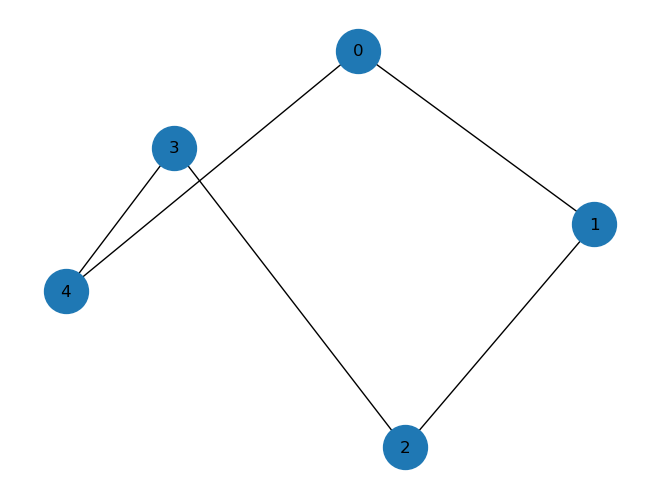

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

#Przykład 2
G = nx.Graph()

G.add_edges_from([
    (0,1),
    (1,2),
    (2,3),
    (3,4),
    (4,0)
])

nx.draw(
    G,
    with_labels=True,
    node_size=1000
)

plt.show()

In [7]:
# Przykład 3

#      1
#     / \
#    /   \
#   0-----2
#   |      \
#   |       \
#   4-------3
#   |
#   |
#   5


adj3 = [
    [1, 2, 4],
    [0, 2],
    [0, 1, 3],
    [2, 4],
    [0, 3, 5],
    [4]
]

print("Lista sąsiedztwa:")
print(adj3)

order = smallest_last_order(adj3)
greedy = greedy_coloring_order(adj3, order)

print("\nKolorowanie zachłanne:")
print_coloring(greedy)

greedy_colors_used = max(greedy) + 1

chi, exact_colors = chromatic_number(adj3)

print("\nKolorowanie minimalne (dokładne):")
print_coloring(exact_colors)

print("\nPorównanie wynikówww:")
print(f"Liczba kolorów w algorytmie zachłannym: {greedy_colors_used}")
print(f"Liczba chromatyczna grafu: {chi}")

Lista sąsiedztwa:
[[1, 2, 4], [0, 2], [0, 1, 3], [2, 4], [0, 3, 5], [4]]

Kolorowanie zachłanne:
Wierzchołek 0 -> kolor 1
Wierzchołek 1 -> kolor 2
Wierzchołek 2 -> kolor 0
Wierzchołek 3 -> kolor 1
Wierzchołek 4 -> kolor 0
Wierzchołek 5 -> kolor 1

Kolorowanie minimalne (dokładne):
Wierzchołek 0 -> kolor 0
Wierzchołek 1 -> kolor 1
Wierzchołek 2 -> kolor 2
Wierzchołek 3 -> kolor 0
Wierzchołek 4 -> kolor 1
Wierzchołek 5 -> kolor 0

Porównanie wynikówww:
Liczba kolorów w algorytmie zachłannym: 3
Liczba chromatyczna grafu: 3
